# Day 12: Overfitting & Regularization

> **Goal:** Understand what overfitting is, how to detect it, and the key techniques to combat it: dropout, weight decay, and early stopping.

---

## What is Overfitting?

A model **overfits** when it memorises the training data instead of learning general patterns.

| | Training set | Validation/Test set |
|---|---|---|
| **Underfitting** | Poor | Poor |
| **Good fit** | Good | Good |
| **Overfitting** | Excellent | Poor |

**Analogy:** Imagine memorising every exam answer vs. understanding the subject. Memorisation fails on a new exam.

### How to detect it
- Training loss keeps decreasing
- Validation loss stops decreasing (or increases)
- The gap between train and val performance widens

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


---
## 1. Setup: Create an Overfitting Scenario

We'll use a **small subset** of MNIST (only 500 samples) with a **large model** — a recipe for overfitting!

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

full_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Use only 500 training samples → easy to overfit!
small_train = Subset(full_train, range(500))

# Split: 400 train, 100 val
train_data, val_data = random_split(small_train, [400, 100],
                                     generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 10.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 370kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 745kB/s]

Train: 400, Val: 100, Test: 10000


### Training Utilities

Below are the same `train_one_epoch`, `evaluate`, and `train_model` helpers from Day 11. We wrap them in a function to easily train different models and compare their training histories.

In [3]:
# Helper functions from Day 11
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        tl, ta = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        vl, va = evaluate(model, val_loader, loss_fn, device)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)
    return history

---
## 2. Demonstrate Overfitting

In [9]:
class BigMLP(nn.Module):
    """A deliberately large model to overfit small data."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model_overfit = BigMLP().to(device)
print(f"Parameters: {sum(p.numel() for p in model_overfit.parameters()):,}")

history_overfit = train_model(model_overfit, train_loader, val_loader, epochs=80)
print(f"\nFinal — Train Acc: {history_overfit['train_acc'][-1]:.2%}, Val Acc: {history_overfit['val_acc'][-1]:.2%}")

Parameters: 567,434

Final — Train Acc: 100.00%, Val Acc: 93.00%


### Spotting Overfitting in the Curves

The `plot_history` function below shows training vs. validation curves side by side. **The gap between the solid line (train) and dashed line (val) is the overfitting signal.** A well-generalizing model will have both lines close together.

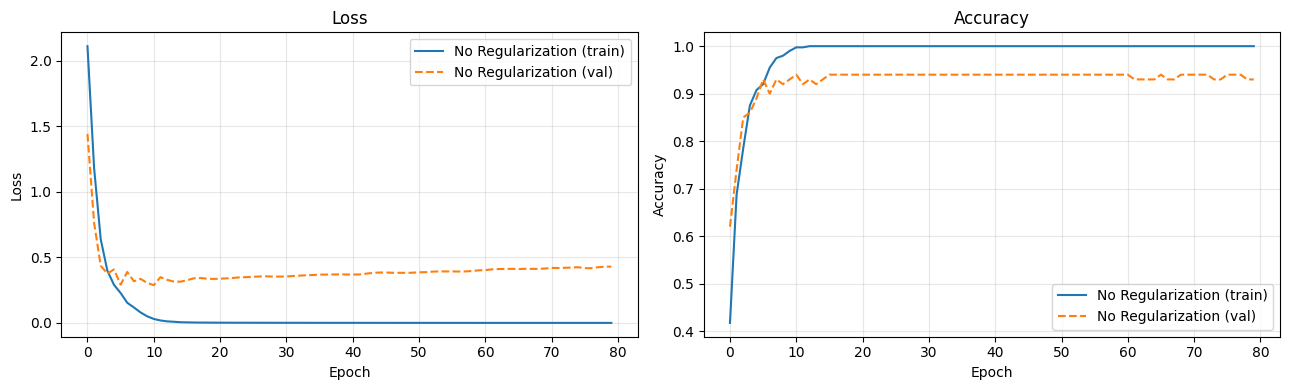

In [5]:
def plot_history(histories, labels):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for h, label in zip(histories, labels):
        ax1.plot(h["train_loss"], label=f"{label} (train)", linestyle="-")
        ax1.plot(h["val_loss"],   label=f"{label} (val)",   linestyle="--")
        ax2.plot(h["train_acc"],  label=f"{label} (train)", linestyle="-")
        ax2.plot(h["val_acc"],    label=f"{label} (val)",   linestyle="--")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss")
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy")
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history([history_overfit], ["No Regularization"])

**What to see:** Training accuracy → ~100%, but validation accuracy plateaus or drops. The gap = overfitting!

---
## 3. Regularization Technique 1: Dropout

**Dropout** randomly "turns off" neurons during training (sets them to 0). This forces the network to be redundant — no single neuron can be relied upon.

- During **training**: each neuron is dropped with probability `p` (e.g., 0.5)
- During **evaluation**: all neurons are active (outputs are scaled automatically)
- This is why `model.train()` and `model.eval()` matter!

In [8]:
class BigMLP_Dropout(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(p),        # ← Drop 50% of neurons
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model_dropout = BigMLP_Dropout(p=0.5).to(device)
history_dropout = train_model(model_dropout, train_loader, val_loader, epochs=80)
print(f"Dropout — Train Acc: {history_dropout['train_acc'][-1]:.2%}, Val Acc: {history_dropout['val_acc'][-1]:.2%}")

Dropout — Train Acc: 99.25%, Val Acc: 91.00%


### Comparing: With vs Without Dropout

In the plot below, compare the **train-val gap** between "No Reg" and "Dropout(0.5)." With dropout, the training accuracy won't reach 100% (because neurons are randomly disabled), but the validation accuracy should be closer to the training accuracy — a sign of better generalization.

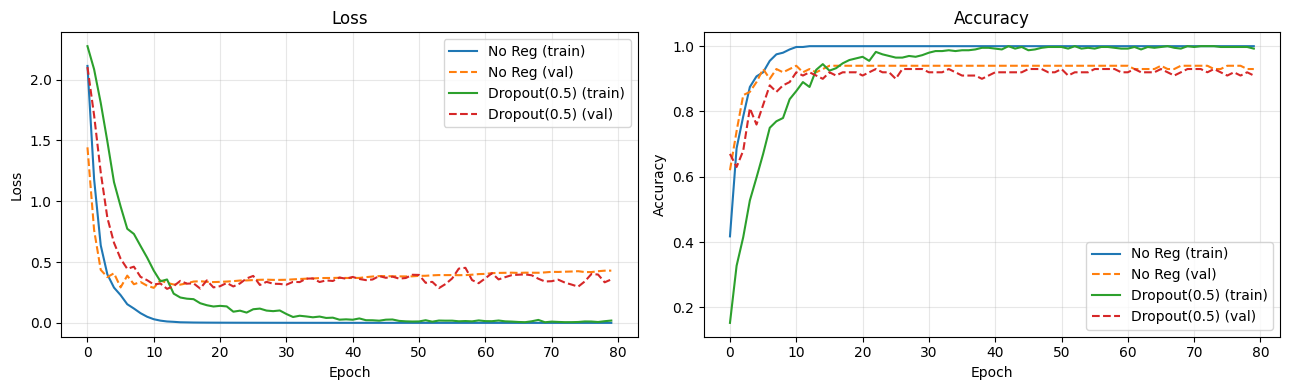

In [7]:
plot_history([history_overfit, history_dropout], ["No Reg", "Dropout(0.5)"])

---
## 4. Regularization Technique 2: Weight Decay (L2)

**Weight decay** adds a penalty on large weights to the loss:

$$\text{Loss}_{\text{total}} = \text{Loss}_{\text{data}} + \lambda \sum w_i^2$$

In PyTorch, you set it in the optimizer:

In [10]:
torch.manual_seed(42)
model_wd = BigMLP().to(device)

# Weight decay = L2 regularization
loss_fn = nn.CrossEntropyLoss()
optimizer_wd = optim.Adam(model_wd.parameters(), lr=1e-3, weight_decay=1e-2)

history_wd = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
for epoch in range(80):
    tl, ta = train_one_epoch(model_wd, train_loader, loss_fn, optimizer_wd, device)
    vl, va = evaluate(model_wd, val_loader, loss_fn, device)
    history_wd["train_loss"].append(tl)
    history_wd["val_loss"].append(vl)
    history_wd["train_acc"].append(ta)
    history_wd["val_acc"].append(va)

print(f"Weight Decay — Train Acc: {history_wd['train_acc'][-1]:.2%}, Val Acc: {history_wd['val_acc'][-1]:.2%}")

Weight Decay — Train Acc: 99.75%, Val Acc: 93.00%


### Comparing All Three Methods

Now we can see all three approaches on the same plot — no regularization, dropout, and weight decay. Look at how each technique trades off training performance for better generalization (smaller train-val gap).

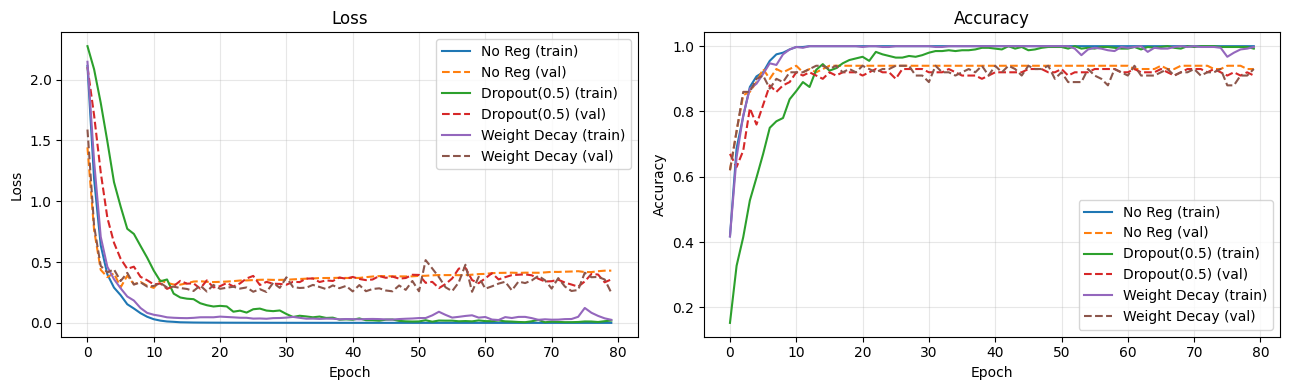

In [11]:
plot_history([history_overfit, history_dropout, history_wd],
             ["No Reg", "Dropout(0.5)", "Weight Decay"])

---
## 5. Regularization Technique 3: Early Stopping

**Idea:** Stop training when validation loss stops improving.

- Track the best validation loss seen so far
- If it doesn't improve for `patience` epochs, stop training
- Optionally save the best model checkpoint

In [12]:
torch.manual_seed(42)
model_es = BigMLP().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer_es = optim.Adam(model_es.parameters(), lr=1e-3)

# Early stopping logic
patience = 10
best_val_loss = float("inf")
epochs_no_improve = 0
best_epoch = 0

history_es = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(200):  # max epochs
    tl, ta = train_one_epoch(model_es, train_loader, loss_fn, optimizer_es, device)
    vl, va = evaluate(model_es, val_loader, loss_fn, device)

    history_es["train_loss"].append(tl)
    history_es["val_loss"].append(vl)
    history_es["train_acc"].append(ta)
    history_es["val_acc"].append(va)

    if vl < best_val_loss:
        best_val_loss = vl
        best_epoch = epoch
        epochs_no_improve = 0
        # Save best model weights
        best_state = {k: v.clone() for k, v in model_es.state_dict().items()}
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"⏹ Early stopping at epoch {epoch+1}! Best epoch: {best_epoch+1}")
        break

# Restore best weights
model_es.load_state_dict(best_state)
print(f"Best Val Loss: {best_val_loss:.4f}")

⏹ Early stopping at epoch 21! Best epoch: 11
Best Val Loss: 0.2880


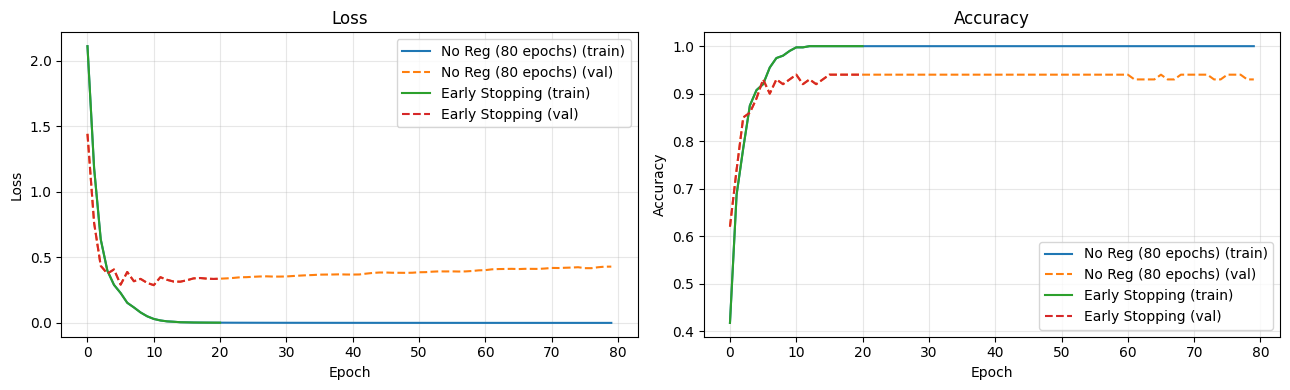

In [13]:
plot_history([history_overfit, history_es], ["No Reg (80 epochs)", "Early Stopping"])

---
## 6. Summary: Regularization Toolkit

| Technique | How it works | When to use |
|---|---|---|
| **Dropout** | Randomly zero out neurons during training | Always a good default for dense layers |
| **Weight Decay (L2)** | Penalize large weights | Works with any optimizer |
| **Early Stopping** | Stop when val loss plateaus | Always — it's free! |
| **Data Augmentation** | Artificially expand training data | When you have limited data (Day 15) |
| **Simpler model** | Fewer parameters | When your model is too large for your data |

In practice, **combine multiple techniques** (dropout + weight decay + early stopping).

---
## 🧪 Exercises

### Exercise 1: Try different dropout rates
Train with `p=0.1`, `p=0.3`, `p=0.7`. Plot all curves. What's the sweet spot?

### Exercise 2: Combine all three
Build a model with Dropout + Weight Decay + Early Stopping. Does it outperform each alone?

### Exercise 3: More data fixes overfitting
Increase training data from 500 to 5000 and 50000. How does overfitting change? Plot the train-val gap.

### Exercise 4: Visualize weight distributions
Plot histograms of weight values from the model trained with and without weight decay. What's different?

In [ ]:
# Exercise 1: Your code here

In [ ]:
# Exercise 2: Your code here

In [ ]:
# Exercise 3: Your code here

In [ ]:
# Exercise 4: Your code here

---
## 📝 Key Takeaways

- **Overfitting** = great training performance, poor validation/test performance
- **Dropout** forces redundancy by randomly disabling neurons
- **Weight decay** penalises large weights, keeping the model simpler
- **Early stopping** saves the model at its best validation point
- Always monitor **train vs. val curves** — they tell you everything!

**Tomorrow:** Batch Normalization and learning rate scheduling — two more tools for faster, more stable training.